In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [301]:
import torch.nn as nn
import torch.optim as optim

In [302]:
df = pd.read_csv("MNIST/mnist_train.csv")

In [303]:
df.sample(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
51313,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45566,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
43356,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59132,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10709,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [304]:
y = df["label"]
x = df.iloc[:,1:]
x = x


In [305]:
x.sample(5)

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
54605,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17747,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16547,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [306]:
y.sample(5)

32683    4
7500     2
2742     4
6383     9
25825    1
Name: label, dtype: int64

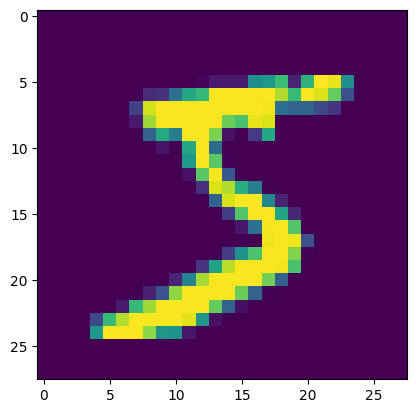

In [307]:
row1 = x.iloc[0].values
img = row1.reshape(28,28)

plt.imshow(img)
# the first image we had was the image of the digit 5.

In [308]:
x = x.sample(frac=1,axis=1,random_state=42)

In [309]:
x.sample(5)

,22x11,22x3,8x14,23x22,7x7,8x18,16x10,10x8,22x6,8x9,...,17x19,5x10,22x27,1x21,26x1,3x16,4x23,10x19,16x16,4x19
102,0,0,250,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24258,0,0,89,0,0,0,139,0,0,0,...,35,0,0,0,0,0,0,0,79,228
11944,0,0,0,0,0,0,0,89,0,0,...,233,0,0,0,0,0,0,0,254,0
51958,247,0,191,0,0,233,45,0,0,0,...,0,0,0,0,0,0,0,184,111,0
7810,61,0,254,0,0,95,0,0,0,0,...,0,0,0,0,0,0,0,0,254,0


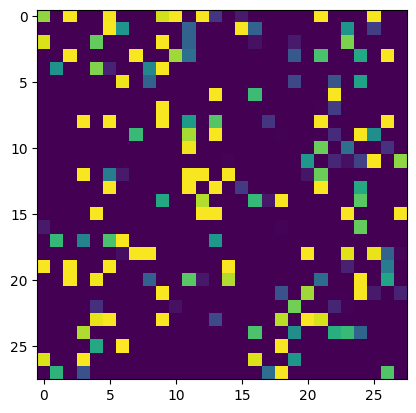

In [310]:
row1 = x.iloc[0].values
img = row1.reshape(28,28)

plt.imshow(img)
# clearly we have lost the spatial information that tells us that the image was of the digit 5.

In [311]:
#using the same FCNN that we had used for the previous part of the question.

class FCNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()
        # define the structure of each layer
        self.input = nn.Linear(28*28, 128) 
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    # the forward pass into the model
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x
    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions
        
model = FCNN() # initializing the model

In [312]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [313]:
X = torch.tensor(x.values, dtype=torch.float32)   # shape: (N, 784)
Y = torch.tensor(y.values, dtype=torch.long)      # shape: (N,)

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}, Loss={loss.item():.4f}")



Epoch 1, Loss=5.0709
Epoch 2, Loss=4.4686
Epoch 3, Loss=2.8395
Epoch 4, Loss=2.4057
Epoch 5, Loss=2.0171
Epoch 6, Loss=1.5677
Epoch 7, Loss=1.2473
Epoch 8, Loss=1.0677
Epoch 9, Loss=0.9502
Epoch 10, Loss=0.8730
Epoch 11, Loss=0.8170
Epoch 12, Loss=0.7455
Epoch 13, Loss=0.6668
Epoch 14, Loss=0.6052
Epoch 15, Loss=0.5607
Epoch 16, Loss=0.5249
Epoch 17, Loss=0.4936
Epoch 18, Loss=0.4678
Epoch 19, Loss=0.4483
Epoch 20, Loss=0.4305
Epoch 21, Loss=0.4090
Epoch 22, Loss=0.3863
Epoch 23, Loss=0.3697
Epoch 24, Loss=0.3597
Epoch 25, Loss=0.3503
Epoch 26, Loss=0.3377
Epoch 27, Loss=0.3243
Epoch 28, Loss=0.3137
Epoch 29, Loss=0.3053
Epoch 30, Loss=0.2963
Epoch 31, Loss=0.2864
Epoch 32, Loss=0.2779
Epoch 33, Loss=0.2711
Epoch 34, Loss=0.2646
Epoch 35, Loss=0.2579
Epoch 36, Loss=0.2513
Epoch 37, Loss=0.2450
Epoch 38, Loss=0.2393
Epoch 39, Loss=0.2342
Epoch 40, Loss=0.2295
Epoch 41, Loss=0.2248
Epoch 42, Loss=0.2200
Epoch 43, Loss=0.2154
Epoch 44, Loss=0.2112
Epoch 45, Loss=0.2069
Epoch 46, Loss=0.20

In [314]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X)                 # X: (N, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y.size(0)
    correct = (predictions == Y).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:.2f}%")


Train Accuracy: 97.33%


In [315]:
model.eval()
correct = 0
total = 0
df2 = pd.read_csv("MNIST/mnist_test.csv")
X_test = df2.iloc[:,1:]
Y_test = df2["label"]
X_test = X_test*10
X_test = X_test.sample(frac=1,axis=1,random_state=42)
X_test = torch.tensor(X_test.values, dtype=torch.float32)   # shape: (N, 784)
Y_test = torch.tensor(Y_test.values, dtype=torch.long)      # shape: (N,)

with torch.no_grad():
    outputs = model(X_test)            # (N_test, 784)
    predictions = torch.argmax(outputs, dim=1)

    total = Y_test.size(0)
    correct = (predictions == Y_test).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.12%
